## Imports

In [19]:
import pandas as pd
import time

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import matthews_corrcoef, accuracy_score
from sklearn.ensemble import RandomForestClassifier

## PreProcess

In [20]:
RS = 678723
data = pd.read_csv("../../data/processed/final_dataset.csv")

feature_cols = [
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'loudness', 'duration_sec', 'popularity'
]

X = data[feature_cols]
y = data['macro_genre']

X.head()

,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_sec,popularity
0,-0.295121,-1.244639,-1.178954,1.049226,-0.691216,-0.537222,-0.393524,0.403917,-0.189488,-0.062859,3.123384
1,0.187328,-0.686411,0.221331,0.437937,-0.691179,-0.624753,-0.528338,0.631455,-0.229613,-0.221997,1.990284
2,-0.696259,-1.499723,-1.156609,0.046373,-0.691079,-0.664042,-0.477093,0.619702,-0.832373,-0.606319,2.430934
3,-0.788412,-1.436876,0.195262,1.367548,-0.691216,-0.712781,-0.445557,2.806734,-0.152002,0.366301,2.493884
4,-0.582422,0.559434,-0.888469,-0.701259,-0.638350,-0.562088,-0.493649,1.695337,0.626921,-0.035059,2.242084


In [21]:
le = LabelEncoder()
y_labels = le.fit_transform(y)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_labels, test_size=0.25, random_state=RS, stratify=y_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=RS, stratify=y_train_val
)

# scaling: fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# DTree

In [30]:
inf = float("inf")
max_depth = [0, 2, 4, 6, 8, 10, 15, 20]

val_mcc = {}
val_acc = {}

for depth in max_depth:
    start_time = time.perf_counter()

    print(f"Depth {depth}...", end="")
    if depth == 0:
        dtc = DecisionTreeClassifier(
            criterion='entropy',
            random_state=RS
        )
    else:
        dtc = DecisionTreeClassifier(
            criterion='entropy',
            max_depth=depth,
            random_state=RS
        )

    dtc.fit(X_train_scaled, y_train)
    y_pred = dtc.predict(X_val_scaled)

    matthews = matthews_corrcoef(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)
    val_mcc[depth] = matthews
    val_acc[depth] = acc


    exec_time = time.perf_counter() - start_time
    print(f"executed in {exec_time:.4f}")


print("~~~~DECISION TREE~~~~")
for depth in val_mcc:
    mcc = val_mcc[depth]
    print(f"{depth}: {mcc}")



Depth 0...executed in 12.0034
Depth 2...executed in 0.9316
Depth 4...executed in 1.9099
Depth 6...executed in 2.9988
Depth 8...executed in 4.3798
Depth 10...executed in 5.4197
Depth 15...executed in 8.7679
Depth 20...executed in 11.2372
~~~~DECISION TREE~~~~
0: 0.3568235920873612
2: 0.32356545069891557
4: 0.36309858011612545
6: 0.3960918729828978
8: 0.42251417722478435
10: 0.44150734843542616
15: 0.44044582782685926
20: 0.38163991798645513


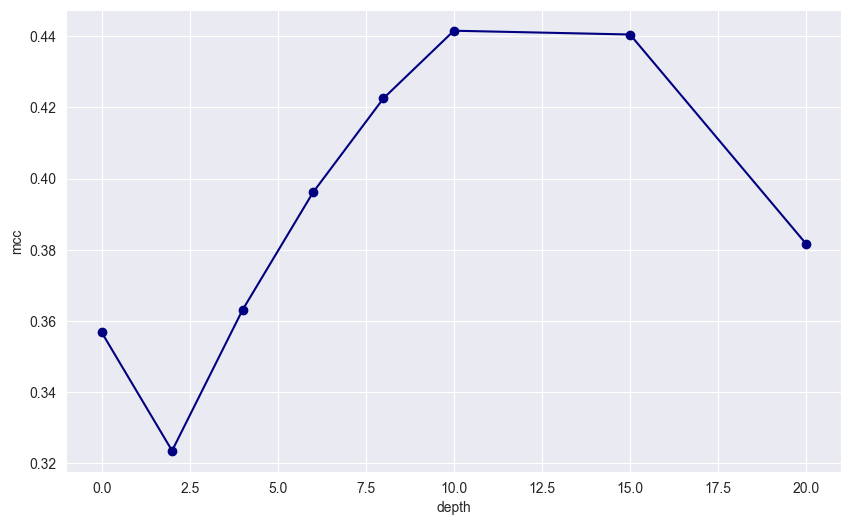

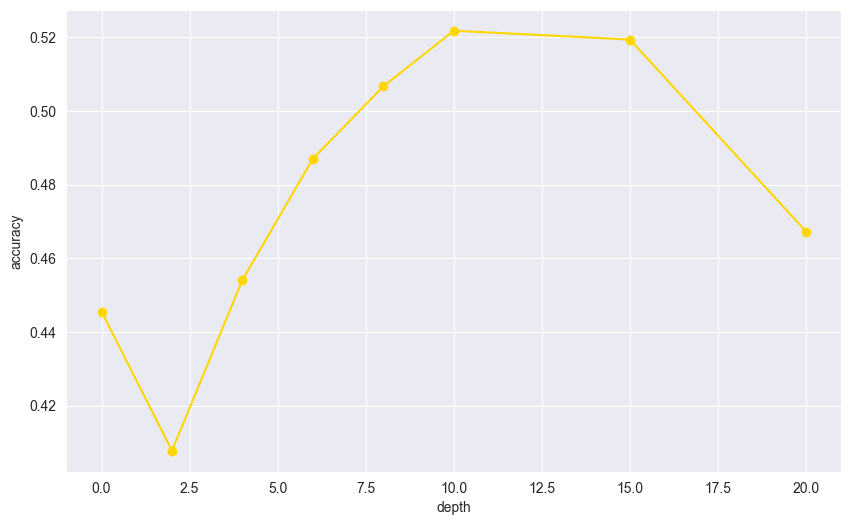

In [31]:
## DT MCC SCORE
fig = (10, 6)

plt.figure(figsize=fig)
plt.plot(max_depth, list(val_mcc.values()), marker="o", color="navy")
plt.xlabel("depth")
plt.ylabel("mcc")
plt.show()


plt.figure(figsize=fig)
plt.plot(max_depth, list(val_acc.values()), marker="o", color="gold")
plt.xlabel("depth")
plt.ylabel("accuracy")

plt.show()